### Data loading

In [1]:
# Load Celligner aligned data
import pandas as pd
file_path = 'E:/TCGA alighned/Celligner_aligned_data.csv'
all = pd.read_csv(file_path,index_col=0)

In [2]:
#EMT
Egene,Mgene = [],[]
with open('../data/EMsig.txt',encoding='utf-8') as f:
    for line in f:
        emsig = line.split()
        if emsig[1] == 'E':Egene.append(emsig[0])
        elif emsig[1] == 'M':Mgene.append(emsig[0])
import requests
r = requests.post(
    url='https://biit.cs.ut.ee/gprofiler/api/convert/convert/',
    json={'organism':'hsapiens','target':'ENSG','query':Egene}).json()['result']
Egene = [x['converted'] for x in r]
r = requests.post(
    url='https://biit.cs.ut.ee/gprofiler/api/convert/convert/',
    json={'organism':'hsapiens','target':'ENSG','query':Mgene}).json()['result']
Mgene = [x['converted'] for x in r]

In [3]:
EMall = all[Egene + Mgene]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
EMall_scaled = pd.DataFrame(scaler.fit_transform(EMall), columns=EMall.columns, index=EMall.index)
EMall_scaled['Escore'] = EMall_scaled[Egene].mean(axis=1)
EMall_scaled['Mscore'] = EMall_scaled[Mgene].mean(axis=1)
EMall_scaled['EMscore'] = EMall_scaled['Mscore'] - EMall_scaled['Escore']

In [4]:
results_df = pd.read_csv('../data/patient_prediction.csv',index_col=0)

### Log-rank test (Fig. 6g, S17a, c, e)

In [5]:
cancer_to_lin = {
    "Adrenal Cancer": "Adrenal Gland",
    "Bile Duct Cancer": "Biliary Tract",
    "Bladder Cancer": "Bladder/Urinary Tract",
    "Bone Cancer": "Bone",
    "Brain Cancer": "CNS/Brain",
    "Breast Cancer": "Breast",
    "Cervical Cancer": "Cervix",
    "Colon/Colorectal Cancer": "Bowel",
    "Endocrine Cancer": "Other",
    "Endometrial/Uterine Cancer": "Uterus",
    "Engineered": "Other",
    "Esophageal Cancer": "Esophagus/Stomach",
    "Eye Cancer": "Eye",
    "Fibroblast": "Fibroblast",
    "Gallbladder Cancer": "Biliary Tract",
    "Gastric Cancer": "Esophagus/Stomach",
    "Germ Cell Cancer": "Embryonal",
    "Head and Neck Cancer": "Head and Neck",
    "Kidney Cancer": "Kidney",
    "Leukemia": "Myeloid",
    "Liposarcoma": "Soft Tissue",
    "Liver Cancer": "Liver",
    "Lung Cancer": "Lung",
    "Lymphoma": "Lymphoid",
    "Myeloma": "Myeloid",
    "Nasopharyngeal Cancer": "Head and Neck",
    "Nerve": "Peripheral Nervous System",
    "Neuroblastoma": "Peripheral Nervous System",
    "Ovarian Cancer": "Ovary/Fallopian Tube",
    "Pancreatic Cancer": "Pancreas",
    "Pineal Cancer": "CNS/Brain",
    "Prostate Cancer": "Prostate",
    "Rhabdoid": "Soft Tissue",
    "Sarcoma": "Soft Tissue",
    "Skin Cancer": "Skin",
    "Teratoma": "Embryonal",
    "Thymus Cancer": "Other",
    "Thyroid Cancer": "Thyroid",
    "Unknown": "Other"
}


In [6]:
import pandas as pd

df_info = pd.read_csv("../data/Celligner_info.csv",index_col=0)
results_df.index = results_df.index
df_clinical = (pd.merge(df_info, results_df, left_index=True, right_index=True))
df_clinical["lineage_new"] = [cancer_to_lin[c] for c in df_clinical["disease"]]
df_clinical['EMscore'] = EMall_scaled['EMscore']
df_clinical_tumor = df_clinical[df_clinical["type"]=="tumor"].copy()

In [7]:
df_death = pd.read_table("../data/clinical.cohort.2024-08-27/clinical.tsv", encoding='ISO-8859-1')
id_to_days = {}
for id, days in zip(df_death["case_submitter_id"], df_death["days_to_death"]):
    if days == "'--":
        continue
    id_to_days[id] = days

id_to_follow = {}
for id, days in zip(df_death["case_submitter_id"], df_death["days_to_last_follow_up"]):
    if days == "'--":
        continue
    id_to_follow[id] = days

submitter_id = ["-".join(i.split("-")[:-1]) for i in df_clinical_tumor.index]

df_clinical_tumor["days"] = [id_to_days.get(i, "ND") for i in submitter_id]
df_clinical_tumor["follow"] = [id_to_follow.get(i, "ND") for i in submitter_id]

C:\Users\ki949\AppData\Local\Temp\ipykernel_46536\724188743.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_death = pd.read_table("../data/clinical.cohort.2024-08-27/clinical.tsv", encoding='ISO-8859-1')


In [ ]:
#Fig. S17a
import pandas as pd
from lifelines.statistics import logrank_test

df_survival = df_clinical_tumor[(df_clinical_tumor["days"] != "ND") | (df_clinical_tumor["follow"] != "ND")]

lineages = df_survival["lineage_new"].unique()
p_values = {}

for lineage in lineages:
    df_lineage = df_survival[df_survival["lineage_new"] == lineage]
    
    data = {"time": [], "event": [], "group": []}
    for d, f in zip(df_lineage["days"], df_lineage["follow"]):
        if d == "ND":
            data["time"].append(int(f))
            data["event"].append(0)
        else:
            data["time"].append(int(d))
            data["event"].append(1)
    
    # Grouping by median
    data["group"] = ["A" if s != 4 else "B" for s in df_lineage["Prediction"]]

    # Convert to DataFrame for easier processing
    df_data = pd.DataFrame(data)
    
    # Log-rank test between groups A and B
    results = logrank_test(
        df_data[df_data["group"] == "A"]["time"],
        df_data[df_data["group"] == "B"]["time"],
        event_observed_A=df_data[df_data["group"] == "A"]["event"],
        event_observed_B=df_data[df_data["group"] == "B"]["event"]
    )
    if pd.isna(results.p_value):
        continue
    # Store the p-value
    p_values[lineage] = results.p_value

import numpy as np
df_p = pd.DataFrame({'Lineage': p_values.keys(), 'p_value': p_values.values()})
from statsmodels.stats.multitest import multipletests
df_p['FDR'] = multipletests(df_p['p_value'], method='fdr_bh')[1]
df_p['-log10_FDR'] = -np.log10(df_p['FDR'])
df_p.sort_values('FDR', inplace=True)
df_p.head()


,Lineage,p_value,FDR,-log10_FDR
3,Lung,5.390549e-07,0.000009,5.064247
0,CNS/Brain,1.795597e-05,0.000144,3.842701
5,Kidney,4.586627e-02,0.244620,0.611508
6,Liver,1.031457e-01,0.412583,0.384489
1,Esophagus/Stomach,2.799868e-01,0.639970,0.193841


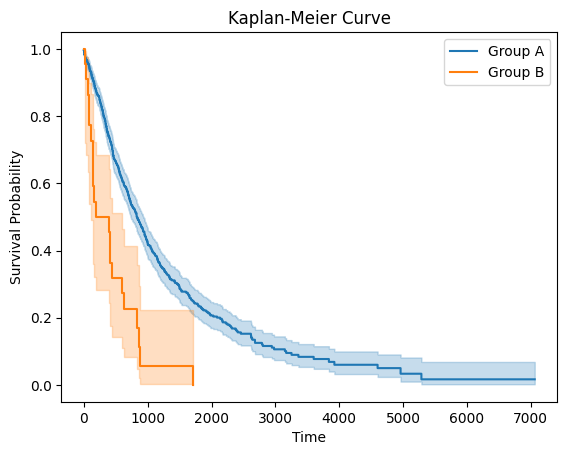

In [ ]:
import pandas as pd
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
from lifelines.statistics import logrank_test

#Fig. 6g, S17c, 17e
df_survival = df_clinical_tumor[(df_clinical_tumor["days"] != "ND") | (df_clinical_tumor["follow"] != "ND")]
df_survival = df_survival[df_survival["lineage_x"]=="lung"]

data = {"time":[],"event":[],"group":[]}#,"amot":[]}
for d, f in zip(df_survival["days"],df_survival["follow"]):
    if d=="ND":
        data["time"].append(int(f))
        data["event"].append(0)
    else:
        data["time"].append(int(d))
        data["event"].append(1)
#df_survival["Prediction"].quantile(0.8)
data["group"] = df_survival["Prediction"]


df = pd.DataFrame(data)
kmf = KaplanMeierFitter()

kmf.fit(durations=df[df['group'] != 4]['time'], event_observed=df[df['group'] != 4]['event'], label='Group A')
ax = kmf.plot_survival_function()

kmf.fit(durations=df[df['group'] == 4]['time'], event_observed=df[df['group'] == 4]['event'], label='Group B')
kmf.plot_survival_function(ax=ax)

plt.title("Kaplan-Meier Curve")
plt.savefig("../result/figure.svg")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

results = logrank_test(
    df[df['group'] != 4]['time'], df[df['group'] == 4]['time'],
    event_observed_A=df[df['group'] != 4]['event'],
    event_observed_B=df[df['group'] == 4]['event']
)



### Adjusted Cox test (Fig. 6g, S17d, f)

In [ ]:
#Lung, No confounders
import numpy as np, pandas as pd
from lifelines import CoxPHFitter

lung = df_clinical_tumor[df_clinical_tumor["lineage_x"]=="lung"].copy()
lung["case_submitter_id"] = ["-".join(str(x).split("-")[:3]) for x in lung.index]
lung["HippoStrong"] = (pd.to_numeric(lung["Prediction"], errors="coerce") == 4).astype(int)
lung = lung.sort_index().drop_duplicates("case_submitter_id")

clin = df_death.copy()
missing = ["'--", "--", "Not Reported", "not reported", "Unknown", "unknown", ""]


clin["event"] = clin["vital_status"].astype(str).str.lower().eq("dead").astype(int)
clin["death"] = pd.to_numeric(clin["days_to_death"].replace(missing, np.nan), errors="coerce")
clin["follow"] = pd.to_numeric(clin["days_to_last_follow_up"].replace(missing, np.nan), errors="coerce")
clin["time"] = np.where(clin["event"].eq(1), clin["death"], clin["follow"])
clin["Age"] = pd.to_numeric(clin["age_at_index"].replace(missing, np.nan), errors="coerce")

stage = clin["ajcc_pathologic_stage"].replace(missing, np.nan).astype("string").str.upper()
stage = stage.str.replace("STAGE", "", regex=False).str.strip()

def stage_group(x):
    if pd.isna(x): return np.nan
    if x.startswith("IV"): return "IV"
    if x.startswith("III"): return "III"
    if x.startswith("II"): return "II"
    if x.startswith("I"): return "I"
    return np.nan

clin["StageGroup"] = stage.map(stage_group)
clin["Subtype"] = clin["project_id"].replace({"TCGA-LUAD":"LUAD", "TCGA-LUSC":"LUSC"})

clin["case_submitter_id"] = clin["case_submitter_id"].astype(str)
clin = clin.sort_values(["case_submitter_id", "time"], ascending=[True, False])
clin = clin.drop_duplicates("case_submitter_id")

cox_df = lung[["case_submitter_id", "HippoStrong","EMscore"]].merge(
    clin[["case_submitter_id", "time", "event", "Age", "StageGroup", "Subtype"]],
    on="case_submitter_id", how="inner"
)

print("after merge:", len(cox_df))
print("\nSubtype:")
print(cox_df["Subtype"].value_counts(dropna=False))
print("\nStage:")
print(cox_df["StageGroup"].value_counts(dropna=False))

cox_df = cox_df.dropna(subset=["time", "event", "HippoStrong", "Age"])
cox_df = cox_df[cox_df["time"] > 0].copy()


cph1 = CoxPHFitter()
cph1.fit(
    cox_df[["time", "event", "HippoStrong"]],
    duration_col="time", event_col="event"
)
print("\n=== Model 1: HippoStrong ===")
cph1.print_summary()

after merge: 665

Subtype:
Subtype
LUSC         303
LUAD         287
TCGA-MESO     75
Name: count, dtype: int64

Stage:
StageGroup
I      277
II     182
III    158
IV      42
NaN      6
Name: count, dtype: int64

=== Model 1: HippoStrong ===


<lifelines.CoxPHFitter: fitted with 652 total observations, 190 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 652
number of events observed = 462
   partial log-likelihood = -2563.46
         time fit was run = 2026-09-30 22:26:09 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
HippoStrong  1.06      2.90      0.23            0.62            1.51                1.86                4.51

             cmp to    z      p  -log2(p)
covariate                                
HippoStrong    0.00 4.73 <0.005     18.75
---
Concordance = 0.52
Partial AIC = 5128.92
log-likelihood ratio test = 16.63 on 1 df
-log2(p) of ll-ratio test = 14.42

In [13]:
#With confounders
#Fig. S17d
cox_model = pd.get_dummies(
    cox_df,
    columns=["StageGroup","Subtype"],
    drop_first=True,
    dtype=int
)

cols = ["time","event","HippoStrong","Age"]
cols += [c for c in cox_model.columns if c.startswith("StageGroup_")]
cols += [c for c in cox_model.columns if c.startswith("GradeGroup_")]
cols += [c for c in cox_model.columns if c.startswith("Subtype_")]
cols += ["EMscore"]

print("\nVariables:")
print(cols)

cph = CoxPHFitter(penalizer=0.01)
cph.fit(cox_model[cols], duration_col="time", event_col="event")
cph.print_summary()


Variables:
['time', 'event', 'HippoStrong', 'Age', 'StageGroup_II', 'StageGroup_III', 'StageGroup_IV', 'Subtype_LUSC', 'Subtype_TCGA-MESO', 'EMscore']


<lifelines.CoxPHFitter: fitted with 652 total observations, 190 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 652
number of events observed = 462
   partial log-likelihood = -2539.36
         time fit was run = 2026-09-30 22:26:21 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
HippoStrong        0.43      1.53      0.26           -0.09            0.94                0.92                2.56
Age                0.01      1.01      0.01            0.00            0.02                1.00                1.03
StageGroup_II      0.42      1.52      0.12            0.19            0.65                1.21                1.92
StageGroup_III     0.58      1.79      0.12            0.34            0.83                1.41                2.28
StageGroup_IV      0.56      1.75      0.20            0.17            0.95                1.19                2.59
Subtype_LUSC      -0.08      0.92      0.11           -0.30            0.13                0.74                1.14
Subtype_TCGA-MESO  0.15      1.16      0.27           -0.38            0.67                0.68                1.96
EMscore            0.13      1.14      0.09           -0.05            0.30                0.95                1.36

                   cmp to     z      p  -log2(p)
covariate                                       
HippoStrong          0.00  1.63   0.10      3.28
Age                  0.00  2.54   0.01      6.50
StageGroup_II        0.00  3.61 <0.005     11.68
StageGroup_III       0.00  4.75 <0.005     18.88
StageGroup_IV        0.00  2.83 <0.005      7.73
Subtype_LUSC         0.00 -0.74   0.46      1.13
Subtype_TCGA-MESO    0.00  0.54   0.59      0.77
EMscore              0.00  1.44   0.15      2.73
---
Concordance = 0.61
Partial AIC = 5094.72
log-likelihood ratio test = 64.82 on 8 df
-log2(p) of ll-ratio test = 34.15

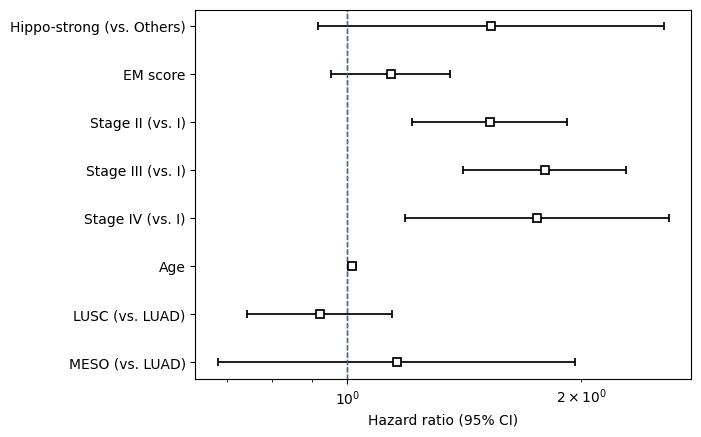

In [14]:
order = ["HippoStrong", "EMscore",  "StageGroup_II", "StageGroup_III",
         "StageGroup_IV","Age", "Subtype_LUSC", "Subtype_TCGA-MESO"]

labels = {
    "HippoStrong": "Hippo-strong (vs. Others)",
    "Age": "Age",
    "StageGroup_II": "Stage II (vs. I)",
    "StageGroup_III": "Stage III (vs. I)",
    "StageGroup_IV": "Stage IV (vs. I)",
    "Subtype_LUSC": "LUSC (vs. LUAD)",
    "Subtype_TCGA-MESO": "MESO (vs. LUAD)",
    "EMscore": "EM score"
}

# lifelines plot is bottom-to-top, so reverse the requested order
plot_order = order[::-1]

ax = cph.plot(hazard_ratios=True, columns=plot_order)
ax.set_yticklabels([labels[x] for x in order])
ax.axvline(1, ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("Hazard ratio (95% CI)")
ax.set_ylabel("")
ax.invert_yaxis()
plt.savefig("../result/figure.svg")

In [ ]:
#Fig. S6g
cox_df.groupby("StageGroup")['HippoStrong'].mean()

StageGroup
I      0.018450
II     0.016760
III    0.058065
IV     0.121951
Name: HippoStrong, dtype: float64

In [18]:
# Brain, no confounders
import numpy as np, pandas as pd
from lifelines import CoxPHFitter

brain = df_clinical_tumor[
    df_clinical_tumor["lineage_x"].astype(str).str.lower().eq("central_nervous_system")
].copy()

brain["case_submitter_id"] = ["-".join(str(x).split("-")[:3]) for x in brain.index]
brain["HippoStrong"] = (pd.to_numeric(brain["Prediction"], errors="coerce") == 4).astype(int)
brain = brain.sort_index().drop_duplicates("case_submitter_id")

clin = df_death.copy()
missing = ["'--", "--", "Not Reported", "not reported", "Unknown", "unknown", ""]
clin["event"] = clin["vital_status"].astype(str).str.lower().eq("dead").astype(int)
clin["death"] = pd.to_numeric(clin["days_to_death"].replace(missing, np.nan), errors="coerce")
clin["follow"] = pd.to_numeric(clin["days_to_last_follow_up"].replace(missing, np.nan), errors="coerce")
clin["time"] = np.where(clin["event"].eq(1), clin["death"], clin["follow"])
clin["Age"] = pd.to_numeric(clin["age_at_index"].replace(missing, np.nan), errors="coerce")

stage = clin["ajcc_pathologic_stage"].replace(missing, np.nan).astype("string").str.upper()
stage = stage.str.replace("STAGE", "", regex=False).str.strip()

def stage_group(x):
    if pd.isna(x): return np.nan
    if x.startswith("IV"): return "IV"
    if x.startswith("III"): return "III"
    if x.startswith("II"): return "II"
    if x.startswith("I"): return "I"
    return np.nan

clin["StageGroup"] = stage.map(stage_group)
clin["Subtype"] = clin["project_id"]#.replace({"TCGA-LUAD":"LUAD", "TCGA-LUSC":"LUSC"})

clin["case_submitter_id"] = clin["case_submitter_id"].astype(str)
clin = clin.sort_values(["case_submitter_id", "time"], ascending=[True, False])
clin = clin.drop_duplicates("case_submitter_id")

cox_df = brain[["case_submitter_id", "HippoStrong", "EMscore"]].merge(
    clin[["case_submitter_id", "time", "event", "Age", "StageGroup", "Subtype"]],
    on="case_submitter_id", how="inner"
)

print("after merge:", len(cox_df))
print("\nSubtype:")
print(cox_df["Subtype"].value_counts(dropna=False))
print("\nStage:")
print(cox_df["StageGroup"].value_counts(dropna=False))

cox_df = cox_df.dropna(subset=["time", "event", "HippoStrong", "Age"])
cox_df = cox_df[cox_df["time"] > 0].copy()

cph1 = CoxPHFitter()
cph1.fit(
    cox_df[["time", "event", "HippoStrong"]],
    duration_col="time", event_col="event"
)
print("\n=== Model 1: HippoStrong + Age + EMscore ===")
cph1.print_summary()

after merge: 387

Subtype:
Subtype
TCGA-LGG    250
TCGA-GBM    137
Name: count, dtype: int64

Stage:
StageGroup
NaN    387
Name: count, dtype: int64

=== Model 1: HippoStrong + Age + EMscore ===


<lifelines.CoxPHFitter: fitted with 385 total observations, 134 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 385
number of events observed = 251
   partial log-likelihood = -1251.48
         time fit was run = 2026-09-30 22:29:45 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
HippoStrong  2.02      7.52      0.60            0.85            3.19                2.34               24.21

             cmp to    z      p  -log2(p)
covariate                                
HippoStrong    0.00 3.38 <0.005     10.45
---
Concordance = 0.51
Partial AIC = 2504.96
log-likelihood ratio test = 6.76 on 1 df
-log2(p) of ll-ratio test = 6.74

In [ ]:
#Brain, with confounders (Fig. S17f)
cox_model = pd.get_dummies(
    cox_df,
    columns=["StageGroup","Subtype"],
    drop_first=True,
    dtype=int
)

cols = ["time","event","HippoStrong","Age"]
cols += [c for c in cox_model.columns if c.startswith("StageGroup_")]
cols += [c for c in cox_model.columns if c.startswith("GradeGroup_")]
cols += [c for c in cox_model.columns if c.startswith("Subtype_")]
cols += ["EMscore"]

print("\nVariables:")
print(cols)

cph = CoxPHFitter(penalizer=0.01)
cph.fit(cox_model[cols], duration_col="time", event_col="event")
cph.print_summary()


Variables:
['time', 'event', 'HippoStrong', 'Age', 'Subtype_TCGA-LGG', 'EMscore']


<lifelines.CoxPHFitter: fitted with 385 total observations, 134 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 385
number of events observed = 251
   partial log-likelihood = -1154.50
         time fit was run = 2026-09-30 22:29:14 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
HippoStrong       2.14      8.49      0.62            0.93            3.35                2.52               28.54
Age               0.04      1.04      0.01            0.03            0.05                1.03                1.05
Subtype_TCGA-LGG -1.11      0.33      0.17           -1.44           -0.78                0.24                0.46
EMscore           0.09      1.09      0.24           -0.39            0.57                0.68                1.76

                  cmp to     z      p  -log2(p)
covariate                                      
HippoStrong         0.00  3.46 <0.005     10.83
Age                 0.00  7.42 <0.005     42.91
Subtype_TCGA-LGG    0.00 -6.57 <0.005     34.23
EMscore             0.00  0.37   0.71      0.50
---
Concordance = 0.78
Partial AIC = 2317.00
log-likelihood ratio test = 200.72 on 4 df
-log2(p) of ll-ratio test = 138.13

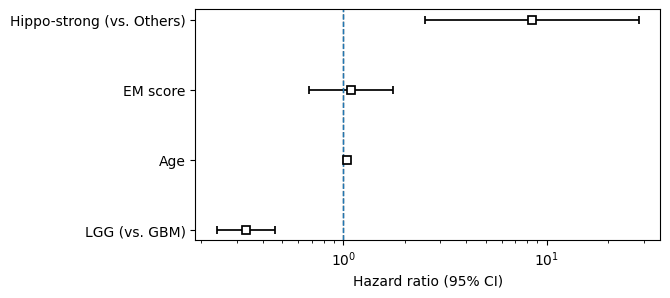

In [82]:
order = ["HippoStrong", "EMscore", "Age", "Subtype_TCGA-LGG"]

labels = {
    "HippoStrong": "Hippo-strong (vs. Others)",
    "Age": "Age",
    "Subtype_TCGA-LGG": "LGG (vs. GBM)",
    "EMscore": "EM score"
}

# lifelines plot is bottom-to-top, so reverse the requested order
plot_order = order[::-1]

plt.figure(figsize=(6, 3))
ax = cph.plot(hazard_ratios=True, columns=plot_order)
ax.set_yticklabels([labels[x] for x in order])
ax.axvline(1, ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("Hazard ratio (95% CI)")
ax.set_ylabel("")
ax.invert_yaxis()
plt.savefig("../result/figure.svg")